In [113]:
# ── IMPORTS ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 100


In [114]:
# ── A1. Load + audit ─────────────────────────────────────────────────
import os

CSV_PATH = "../data/oil_well.csv"
XLSX_PATH = "../data/oil_well.xlsx"

if os.path.exists(XLSX_PATH):
    raw = pd.read_excel(XLSX_PATH, header=None)
elif os.path.exists(CSV_PATH):
    raw = pd.read_csv(CSV_PATH, header=None)
else:
    raise FileNotFoundError("Put oil_well.csv or oil_well.xlsx in ../data/ first")

header_row_idx = 0
for i in range(min(10, len(raw))):
    row_values = raw.iloc[i].astype(str).str.strip()
    if row_values.eq("Date").any():
        header_row_idx = i
        break

df = raw.iloc[header_row_idx + 1:].copy()
df.columns = [str(c).strip() for c in raw.iloc[header_row_idx]]
df = df.reset_index(drop=True)

for c in df.columns:
    if c != "Date":
        df[c] = pd.to_numeric(df[c], errors="coerce")

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df.head()


Shape: (2939, 9)

Columns: ['Date', 'Oil volume (m3/day)', 'Volume of liquid (m3/day)', 'Gas volume (m3/day)', 'Water volume (m3/day)', 'Water cut (%)', 'Working hours', 'Dynamic level (m)', 'Reservoir pressure (atm)']

Dtypes:
 Date                         object
Oil volume (m3/day)           int64
Volume of liquid (m3/day)     int64
Gas volume (m3/day)           int64
Water volume (m3/day)         int64
Water cut (%)                 int64
Working hours                 int64
Dynamic level (m)             int64
Reservoir pressure (atm)      int64
dtype: object

Missing values:
 Date                         0
Oil volume (m3/day)          0
Volume of liquid (m3/day)    0
Gas volume (m3/day)          0
Water volume (m3/day)        0
Water cut (%)                0
Working hours                0
Dynamic level (m)            0
Reservoir pressure (atm)     0
dtype: int64

Duplicate rows: 0


,Date,Oil volume (m3/day),Volume of liquid (m3/day),Gas volume (m3/day),Water volume (m3/day),Water cut (%),Working hours,Dynamic level (m),Reservoir pressure (atm)
0,2013-01-01 00:00:00,49,70,13055,21,29,24,1819,214
1,2013-01-02 00:00:00,49,70,13055,21,29,24,1836,214
2,2013-01-03 00:00:00,49,70,13055,21,29,24,1788,214
3,2013-01-04 00:00:00,49,70,13055,21,29,24,1789,214
4,2013-01-05 00:00:00,44,70,11768,26,36,24,1825,214


In [115]:
# Target: daily oil production volume — the natural regression target for this dataset.
TARGET_COLUMN = "Oil volume (m3/day)"

assert TARGET_COLUMN in df.columns, f"'{TARGET_COLUMN}' not found — check df.columns above and fix TARGET_COLUMN"
print(df[TARGET_COLUMN].describe())


count    2939.000000
mean       17.624362
std         9.689026
min         0.000000
25%        11.000000
50%        15.000000
75%        22.000000
max        49.000000
Name: Oil volume (m3/day), dtype: float64


In [116]:
#Convert the date into useful numeric features like year and month, then remove the original date column
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    df["year"] = df["Date"].dt.year
    df["month"] = df["Date"].dt.month
    df["day_of_year"] = df["Date"].dt.dayofyear
    df = df.drop(columns=["Date"])
    print("Parsed Date -> year, month, day_of_year; dropped raw Date column")


Parsed Date -> year, month, day_of_year; dropped raw Date column


### **EDA visualisations + insight commentary**

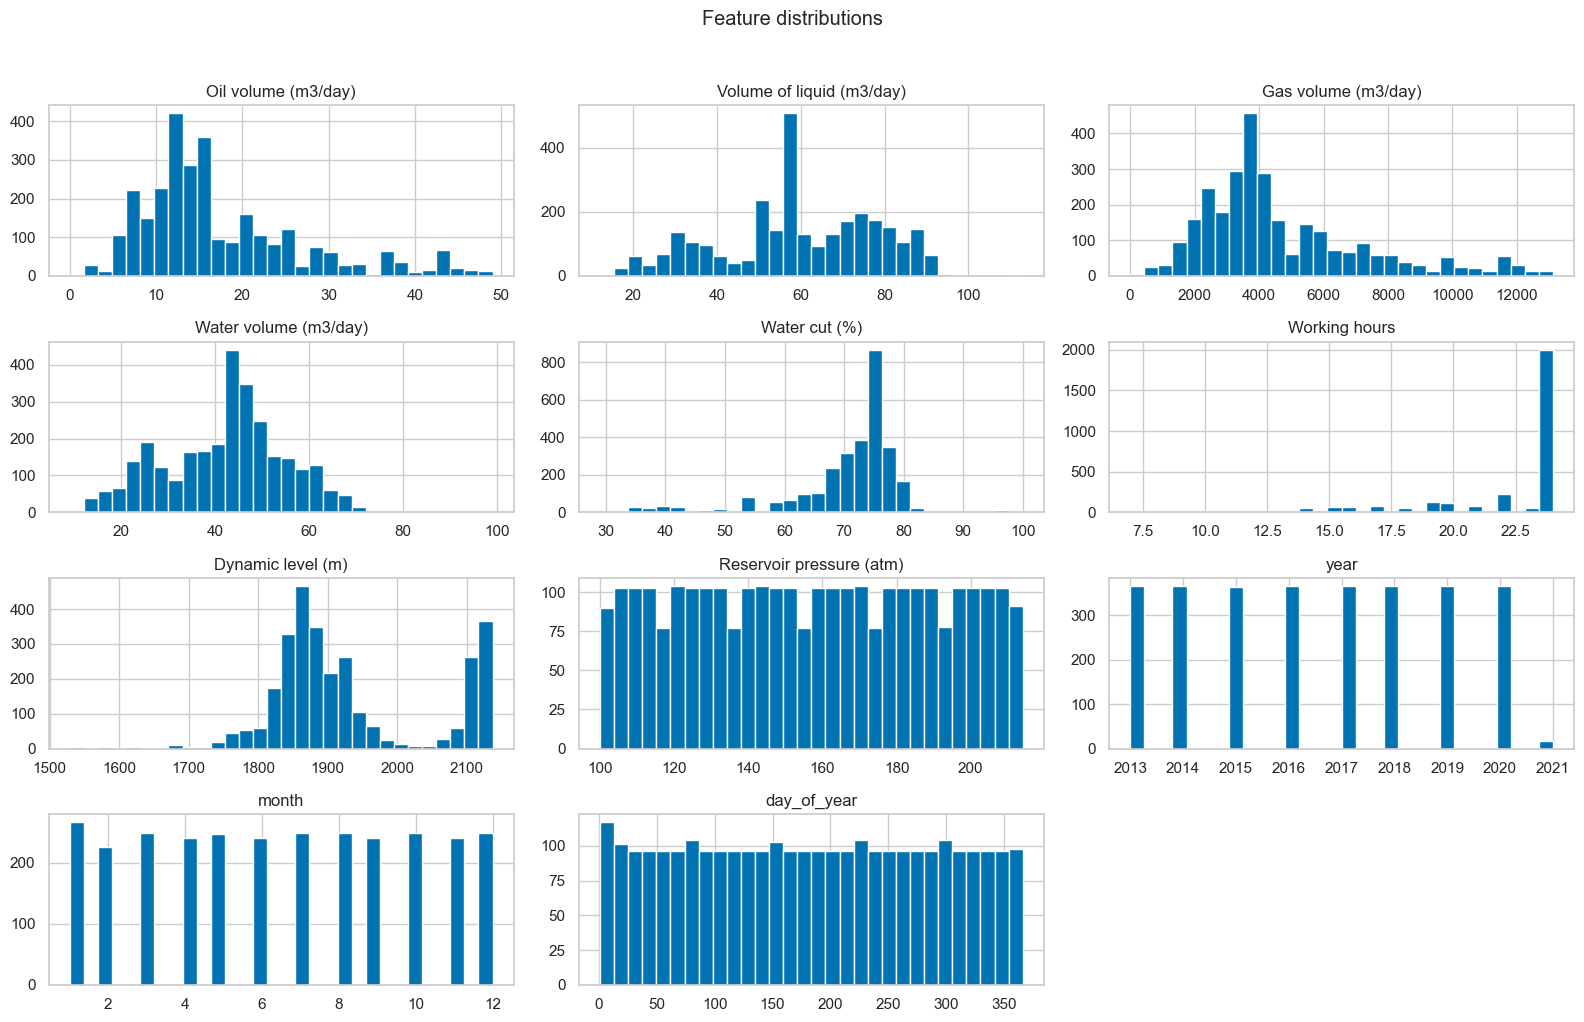

In [117]:
# Distribution plots for numeric features
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols].hist(bins=30, figsize=(16, 10))
plt.suptitle("Feature distributions", y=1.02)
plt.tight_layout()
plt.savefig("../models/eda_distributions.png", bbox_inches="tight")
plt.show()


**Observation:** *note any skewed features, obvious outlier ranges, or unexpected spikes here.*

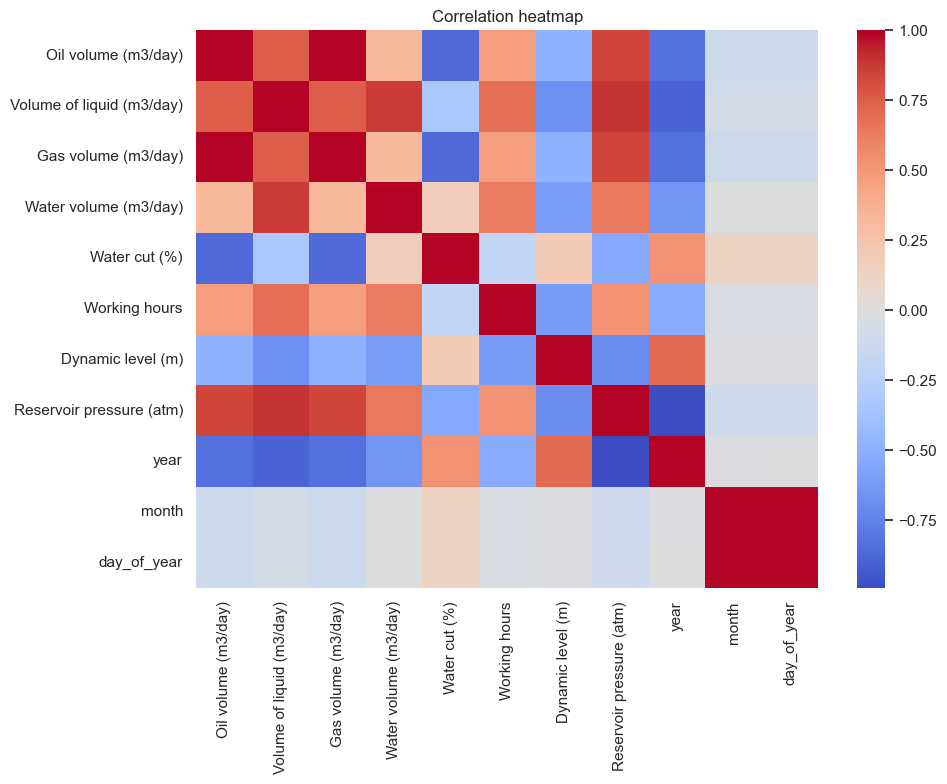

In [118]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.savefig("../models/eda_correlation.png", bbox_inches="tight")
plt.show()


**Observation:** *note which features correlate most strongly with `TARGET_COLUMN`, and any multicollinearity between predictors.*

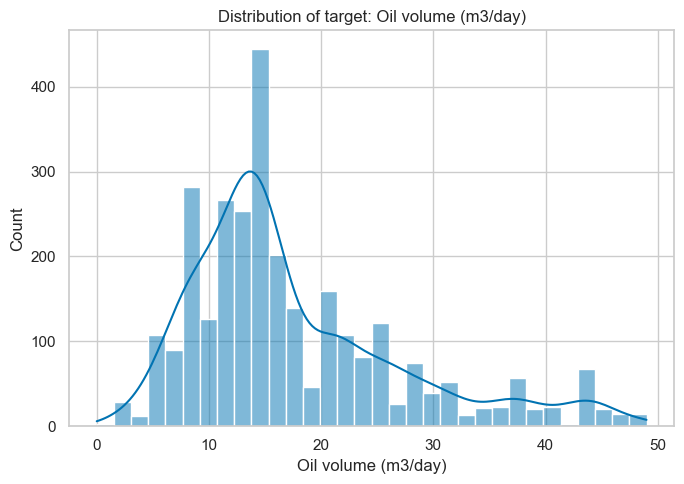

In [119]:
# Target distribution
plt.figure(figsize=(7, 5))
sns.histplot(df[TARGET_COLUMN], kde=True)
plt.title(f"Distribution of target: {TARGET_COLUMN}")
plt.tight_layout()
plt.savefig("../models/eda_target_dist.png", bbox_inches="tight")
plt.show()


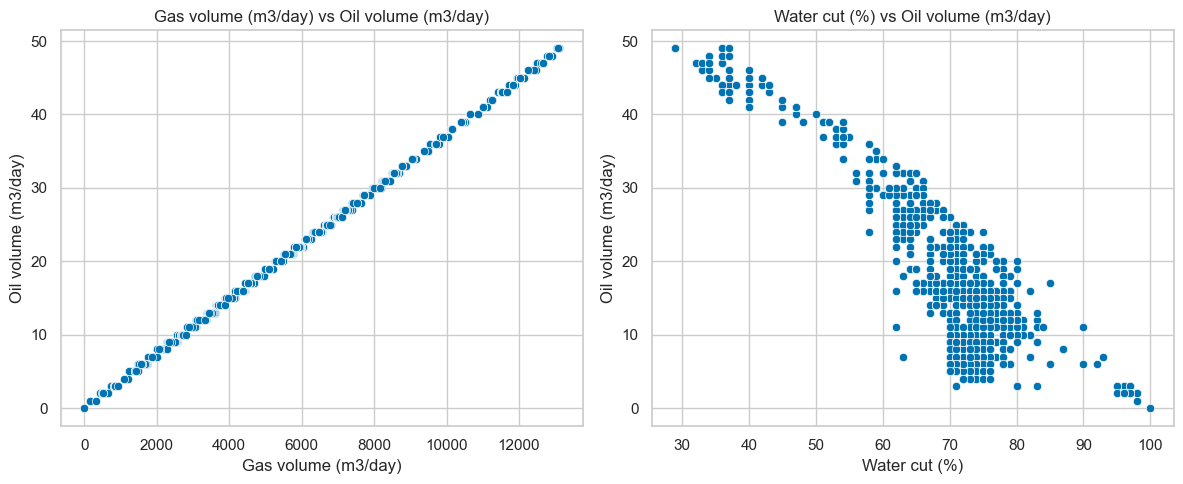

In [120]:
#  two scatter plots: feature vs target
top_corr_features = corr[TARGET_COLUMN].abs().sort_values(ascending=False).index[1:3]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, feat in zip(axes, top_corr_features):
    sns.scatterplot(data=df, x=feat, y=TARGET_COLUMN, ax=ax)
    ax.set_title(f"{feat} vs {TARGET_COLUMN}")
plt.tight_layout()
plt.savefig("../models/eda_scatter.png", bbox_inches="tight")
plt.show()


**Observation:** *describe the relationship shape (linear/non-linear/none) you see for these two features.*

###  **Cleaning: missing values, duplicates, outliers**

In [121]:
# Missing values: numeric -> median, categorical -> mode (justified: robust to outliers/skew)
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

for c in num_cols:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].median())

for c in cat_cols:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].mode()[0])

# Duplicates
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} duplicate rows")

assert df.isnull().sum().sum() == 0, "Still missing values — check columns above"


Dropped 0 duplicate rows


In [122]:
# IQR outlier check + capping on numeric columns (excluding target so we don't distort it blindly)
def iqr_bounds(s, k=1.5):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

outlier_report = {}
for c in [x for x in num_cols if x != TARGET_COLUMN]:
    lo, hi = iqr_bounds(df[c])
    n_out = ((df[c] < lo) | (df[c] > hi)).sum()
    outlier_report[c] = n_out
    if n_out > 0:
        df[c] = df[c].clip(lo, hi)  # cap rather than drop, to preserve sample size

pd.Series(outlier_report, name="outliers_capped").sort_values(ascending=False)


Working hours                357
Water cut (%)                312
Gas volume (m3/day)          178
Water volume (m3/day)         13
Dynamic level (m)             13
Volume of liquid (m3/day)      2
Reservoir pressure (atm)       0
year                           0
month                          0
day_of_year                    0
Name: outliers_capped, dtype: int64

**Justification:** capping (winsorising) at the 1.5×IQR fences is used instead of dropping rows, so genuine but extreme readings are retained without letting a handful of rows dominate scale-sensitive models like SVR/KNN.

###  **Feature engineering**

In [123]:
# Create a meaningful feature to capture relationships between variables.
numeric_predictors = [c for c in num_cols if c != TARGET_COLUMN]
if len(numeric_predictors) >= 2:
    a, b = numeric_predictors[0], numeric_predictors[1]
    df[f"{a}_per_{b}"] = df[a] / df[b].replace(0, np.nan)
    df[f"{a}_per_{b}"] = df[f"{a}_per_{b}"].fillna(df[f"{a}_per_{b}"].median())
    print(f"Engineered feature added: {a}_per_{b}")


Engineered feature added: Volume of liquid (m3/day)_per_Gas volume (m3/day)


**Justification:** This ratio feature helps compare production relative to well depth, making the data more meaningful than using raw values alone.

### **Encoding, scaling, splitting**

In [124]:
# Encode categoricals: one-hot for nominal columns
cat_cols = [c for c in df.select_dtypes(exclude=[np.number]).columns if c != TARGET_COLUMN]
df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=True) if cat_cols else df.copy()

X = df_enc.drop(columns=[TARGET_COLUMN])
y = df_enc[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Train:", X_train_scaled.shape, "Test:", X_test_scaled.shape)


Train: (2351, 11) Test: (588, 11)


# Visualisation code for trained models

In [125]:
# ============================================================
# CLEAR ACTUAL VS PREDICTED PLOT [for trained models]
# ============================================================

def plot_actual_vs_predicted(model, X_test, y_test, title):

    y_pred = model.predict(X_test)

    plt.figure(figsize=(9, 7))

    # Scatter datapoints
    plt.scatter(
        y_test,
        y_pred,
        s=35,
        alpha=0.55,
        edgecolors="black",
        linewidths=0.4,
        label="Test datapoints"
    )

    # Ideal prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--",
        linewidth=2,
        label="Ideal: Actual = Predicted"
    )

    plt.xlabel("Actual Oil Volume (m3/day)", fontsize=12)
    plt.ylabel("Predicted Oil Volume (m3/day)", fontsize=12)

    plt.title(title, fontsize=14)

    plt.legend(fontsize=10)

    plt.grid(True, alpha=0.25)

    # Make both axes have the same scale
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)

    plt.tight_layout()
    plt.show()

###  **10 regression algorithms + comparison table**

Each model follows the same 4-line pattern: instantiate → fit → predict → score.
Results are collected into one summary table, ranked by R².


In [126]:
results = []
all_regression_models = {}   # name -> fitted model/pipeline, saved so the GUI can query any of them

def evaluate(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    r2 = r2_score(y_te, pred)
    rmse = mean_squared_error(y_te, pred) ** 0.5
    mae = mean_absolute_error(y_te, pred)
    results.append({"Model": name, "R2": r2, "RMSE": rmse, "MAE": mae})
    all_regression_models[name] = model
    print(f"{name:28s} R2={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}")
    return model


In [127]:
# 1. Linear Regression — baseline; interpret coefficients
lin = evaluate("Linear Regression", LinearRegression(), X_train_scaled, X_test_scaled, y_train, y_test)


Linear Regression            R2=0.9970  RMSE=0.5285  MAE=0.3719


In [128]:
# 2. Ridge Regression — L2 regularisation
ridge = evaluate("Ridge Regression", Ridge(alpha=1.0, random_state=RANDOM_STATE), X_train_scaled, X_test_scaled, y_train, y_test)


Ridge Regression             R2=0.9969  RMSE=0.5428  MAE=0.3793


In [129]:
# 3. Lasso Regression — L1 regularisation; watch for feature sparsity
lasso = evaluate("Lasso Regression", Lasso(alpha=0.01, random_state=RANDOM_STATE), X_train_scaled, X_test_scaled, y_train, y_test)
print("Non-zero coefficients:", np.sum(lasso.coef_ != 0), "/", len(lasso.coef_))


Lasso Regression             R2=0.9965  RMSE=0.5701  MAE=0.3867
Non-zero coefficients: 9 / 11


In [130]:
# 4. ElasticNet Regression — combined L1 + L2
enet = evaluate("ElasticNet Regression", ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=RANDOM_STATE), X_train_scaled, X_test_scaled, y_train, y_test)


ElasticNet Regression        R2=0.9954  RMSE=0.6577  MAE=0.4405


In [131]:
# 5. Polynomial Regression fits a curved relationship between the input features and target by using different polynomial degrees.from sklearn.pipeline import Pipeline
from sklearn.pipeline import Pipeline
for deg in [2, 3]:
    poly_pipeline = Pipeline([
        ("poly", PolynomialFeatures(degree=deg, include_bias=False)),
        ("linreg", LinearRegression()),
    ])
    evaluate(f"Polynomial Regression (deg={deg})", poly_pipeline, X_train_scaled, X_test_scaled, y_train, y_test)


Polynomial Regression (deg=2) R2=0.9993  RMSE=0.2594  MAE=0.1977
Polynomial Regression (deg=3) R2=0.9854  RMSE=1.1722  MAE=0.2374


In [132]:
# 6. Decision Tree Regressor — tune max_depth, show feature importance
dtree = evaluate("Decision Tree Regressor", DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE), X_train_scaled, X_test_scaled, y_train, y_test)


Decision Tree Regressor      R2=0.9989  RMSE=0.3237  MAE=0.0593


In [133]:
# 7. Random Forest Regressor — ensemble baseline
rf = evaluate("Random Forest Regressor", RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE), X_train_scaled, X_test_scaled, y_train, y_test)


Random Forest Regressor      R2=0.9997  RMSE=0.1741  MAE=0.0294


In [134]:
# 8. Gradient Boosting Regressor
gbr = evaluate("Gradient Boosting Regressor", GradientBoostingRegressor(random_state=RANDOM_STATE), X_train_scaled, X_test_scaled, y_train, y_test)


Gradient Boosting Regressor  R2=0.9995  RMSE=0.2057  MAE=0.0422


In [135]:
# 9. Support Vector Regressor — features already scaled above
svr = evaluate("Support Vector Regressor", SVR(C=1.0, kernel="rbf"), X_train_scaled, X_test_scaled, y_train, y_test)


Support Vector Regressor     R2=0.9940  RMSE=0.7533  MAE=0.4219


In [136]:
# 10. K-Nearest Neighbors Regressor — scaling matters a lot here
knn = evaluate("KNN Regressor", KNeighborsRegressor(n_neighbors=7), X_train_scaled, X_test_scaled, y_train, y_test)


KNN Regressor                R2=0.9940  RMSE=0.7524  MAE=0.4568


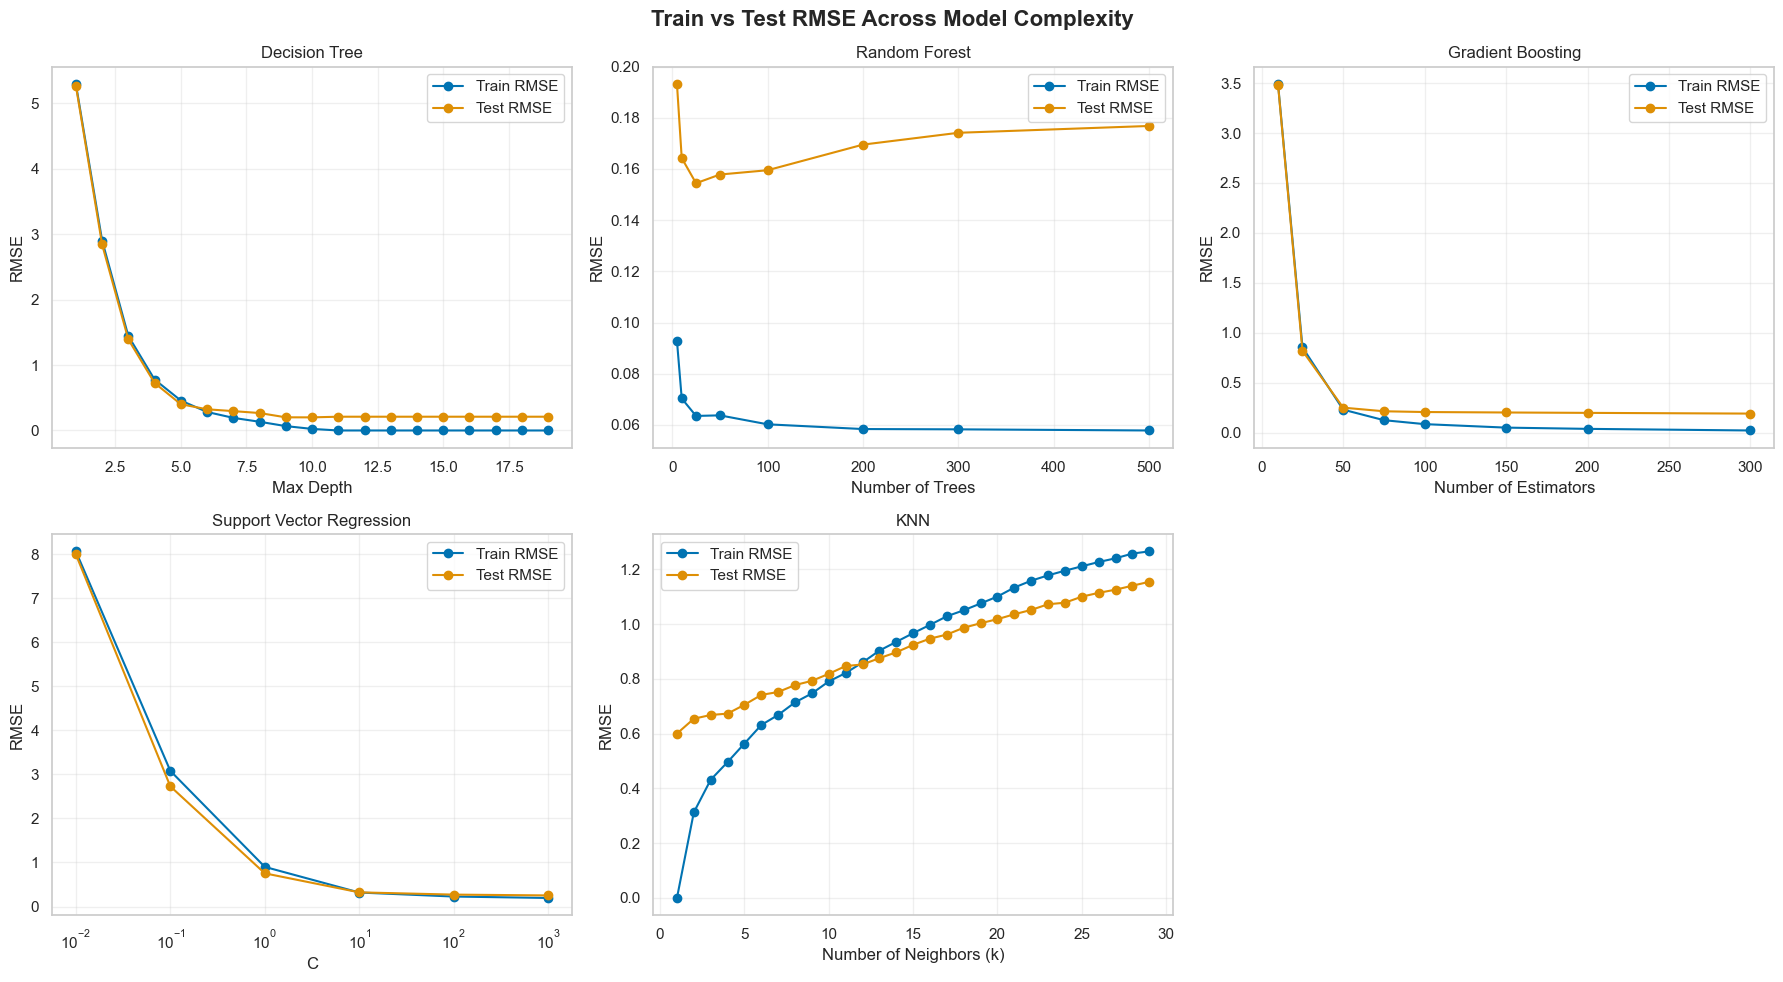

In [137]:
# ============================================================
# TRAIN VS TEST RMSE - COMPLEXITY GRAPHS IN ONE GRID
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()


# ------------------------------------------------------------
# 1. DECISION TREE
# ------------------------------------------------------------

depths = range(1, 20)

train_rmse_dt = []
test_rmse_dt = []

for depth in depths:

    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=RANDOM_STATE
    )

    model.fit(X_train_scaled, y_train)

    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    train_rmse_dt.append(
        np.sqrt(mean_squared_error(y_train, train_pred))
    )

    test_rmse_dt.append(
        np.sqrt(mean_squared_error(y_test, test_pred))
    )

axes[0].plot(depths, train_rmse_dt, marker="o", label="Train RMSE")
axes[0].plot(depths, test_rmse_dt, marker="o", label="Test RMSE")

axes[0].set_title("Decision Tree")
axes[0].set_xlabel("Max Depth")
axes[0].set_ylabel("RMSE")
axes[0].legend()
axes[0].grid(True, alpha=0.3)


# ------------------------------------------------------------
# 2. RANDOM FOREST
# ------------------------------------------------------------

n_trees = [5, 10, 25, 50, 100, 200, 300, 500]

train_rmse_rf = []
test_rmse_rf = []

for n in n_trees:

    model = RandomForestRegressor(
        n_estimators=n,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model.fit(X_train_scaled, y_train)

    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    train_rmse_rf.append(
        np.sqrt(mean_squared_error(y_train, train_pred))
    )

    test_rmse_rf.append(
        np.sqrt(mean_squared_error(y_test, test_pred))
    )

axes[1].plot(n_trees, train_rmse_rf, marker="o", label="Train RMSE")
axes[1].plot(n_trees, test_rmse_rf, marker="o", label="Test RMSE")

axes[1].set_title("Random Forest")
axes[1].set_xlabel("Number of Trees")
axes[1].set_ylabel("RMSE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)


# ------------------------------------------------------------
# 3. GRADIENT BOOSTING
# ------------------------------------------------------------

n_estimators = [10, 25, 50, 75, 100, 150, 200, 300]

train_rmse_gbr = []
test_rmse_gbr = []

for n in n_estimators:

    model = GradientBoostingRegressor(
        n_estimators=n,
        random_state=RANDOM_STATE
    )

    model.fit(X_train_scaled, y_train)

    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    train_rmse_gbr.append(
        np.sqrt(mean_squared_error(y_train, train_pred))
    )

    test_rmse_gbr.append(
        np.sqrt(mean_squared_error(y_test, test_pred))
    )

axes[2].plot(n_estimators, train_rmse_gbr, marker="o", label="Train RMSE")
axes[2].plot(n_estimators, test_rmse_gbr, marker="o", label="Test RMSE")

axes[2].set_title("Gradient Boosting")
axes[2].set_xlabel("Number of Estimators")
axes[2].set_ylabel("RMSE")
axes[2].legend()
axes[2].grid(True, alpha=0.3)


# ------------------------------------------------------------
# 4. SVR
# ------------------------------------------------------------

C_values = [0.01, 0.1, 1, 10, 100, 1000]

train_rmse_svr = []
test_rmse_svr = []

for c in C_values:

    model = SVR(
        C=c,
        kernel="rbf"
    )

    model.fit(X_train_scaled, y_train)

    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    train_rmse_svr.append(
        np.sqrt(mean_squared_error(y_train, train_pred))
    )

    test_rmse_svr.append(
        np.sqrt(mean_squared_error(y_test, test_pred))
    )

axes[3].plot(C_values, train_rmse_svr, marker="o", label="Train RMSE")
axes[3].plot(C_values, test_rmse_svr, marker="o", label="Test RMSE")

axes[3].set_xscale("log")
axes[3].set_title("Support Vector Regression")
axes[3].set_xlabel("C")
axes[3].set_ylabel("RMSE")
axes[3].legend()
axes[3].grid(True, alpha=0.3)


# ------------------------------------------------------------
# 5. KNN
# ------------------------------------------------------------

k_values = range(1, 30)

train_rmse_knn = []
test_rmse_knn = []

for k in k_values:

    model = KNeighborsRegressor(
        n_neighbors=k
    )

    model.fit(X_train_scaled, y_train)

    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    train_rmse_knn.append(
        np.sqrt(mean_squared_error(y_train, train_pred))
    )

    test_rmse_knn.append(
        np.sqrt(mean_squared_error(y_test, test_pred))
    )

axes[4].plot(k_values, train_rmse_knn, marker="o", label="Train RMSE")
axes[4].plot(k_values, test_rmse_knn, marker="o", label="Test RMSE")

axes[4].set_title("KNN")
axes[4].set_xlabel("Number of Neighbors (k)")
axes[4].set_ylabel("RMSE")
axes[4].legend()
axes[4].grid(True, alpha=0.3)


# ------------------------------------------------------------
# EMPTY 6TH SUBPLOT
# ------------------------------------------------------------

axes[5].axis("off")


# ------------------------------------------------------------
# MAIN TITLE
# ------------------------------------------------------------

plt.suptitle(
    "Train vs Test RMSE Across Model Complexity",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

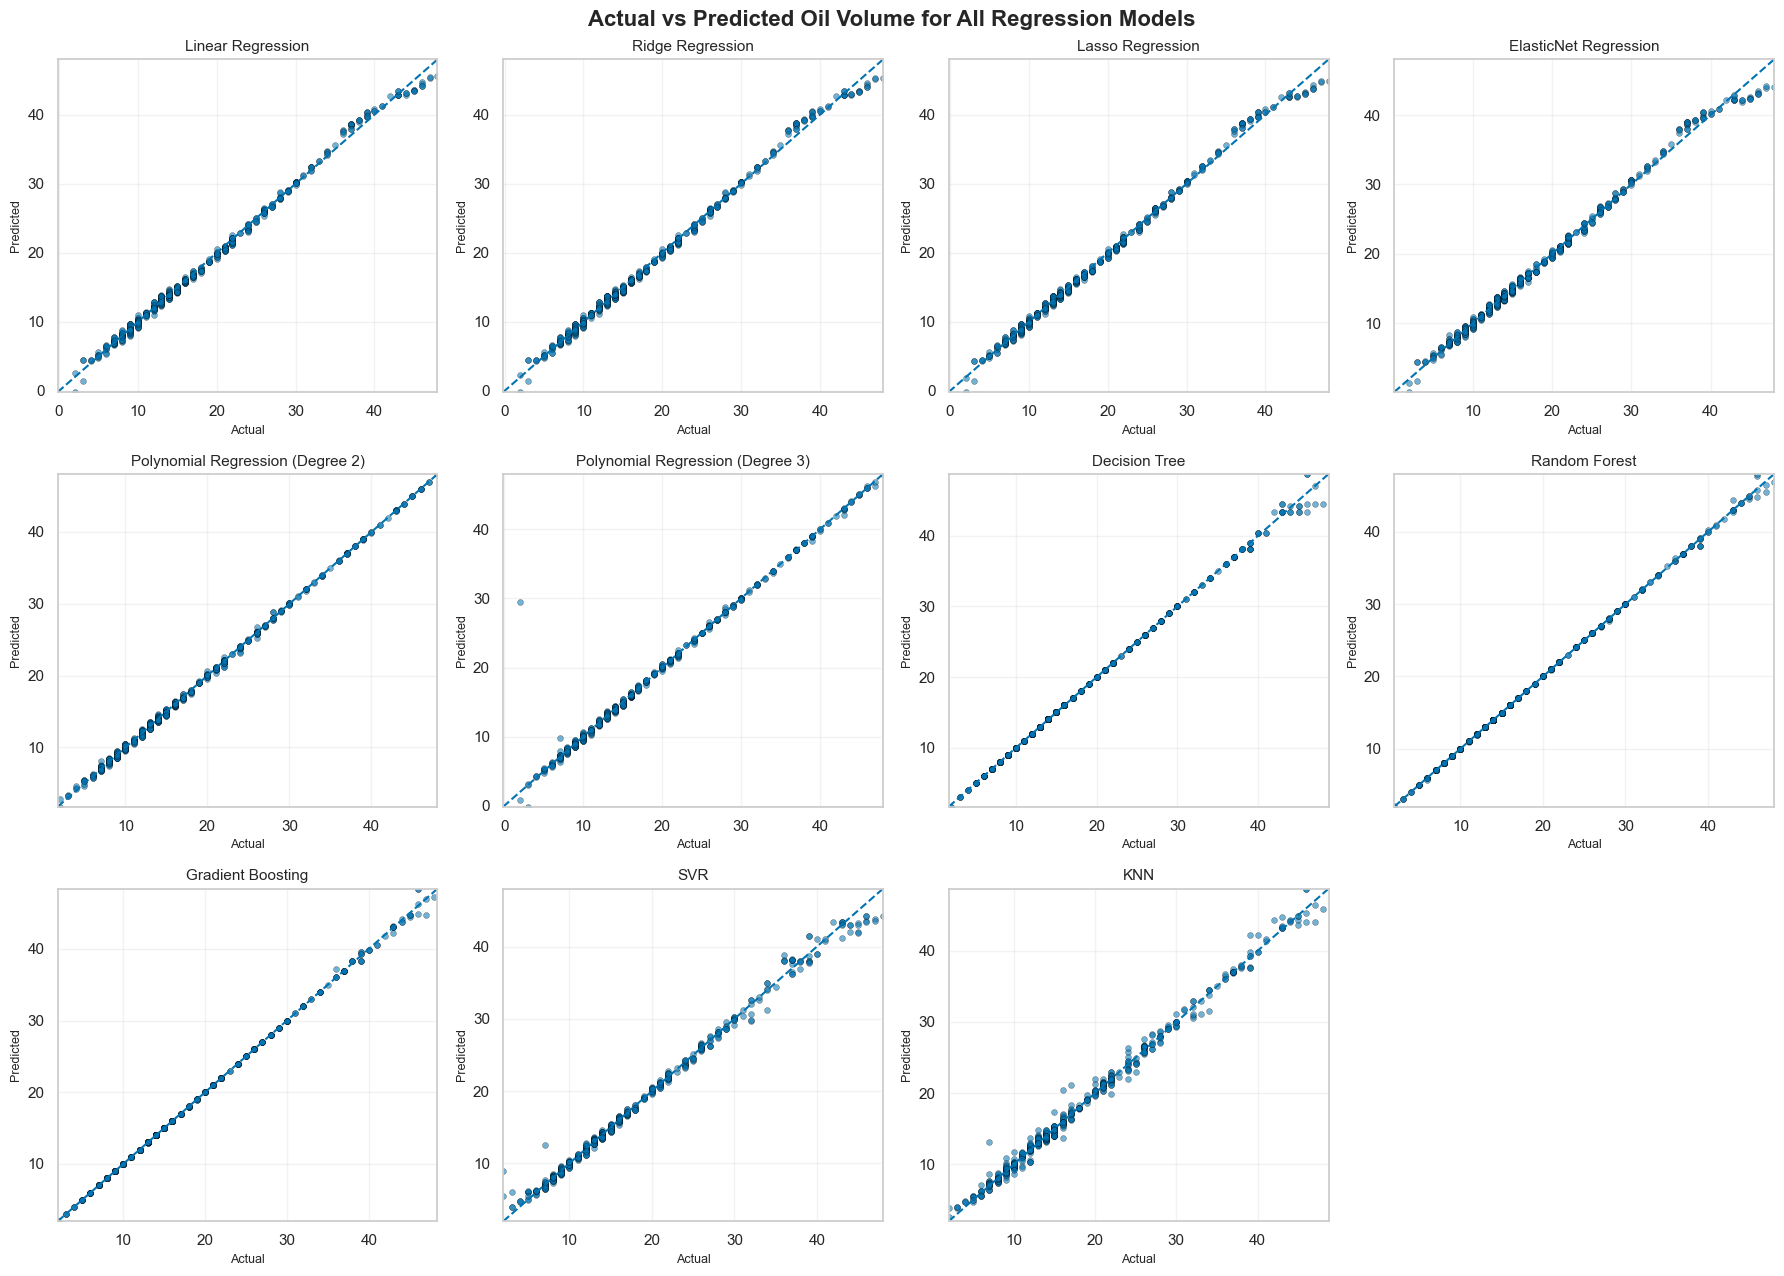

In [138]:
# ============================================================
# ACTUAL VS PREDICTED - ALL MODELS IN ONE GRID
# ============================================================

models = [
    ("Linear Regression", lin),
    ("Ridge Regression", ridge),
    ("Lasso Regression", lasso),
    ("ElasticNet Regression", enet),
    ("Polynomial Regression (Degree 2)", None),
    ("Polynomial Regression (Degree 3)", None),
    ("Decision Tree", dtree),
    ("Random Forest", rf),
    ("Gradient Boosting", gbr),
    ("SVR", svr),
    ("KNN", knn)
]

# Create polynomial models
poly2 = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("linreg", LinearRegression())
])

poly3 = Pipeline([
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
    ("linreg", LinearRegression())
])

poly2.fit(X_train_scaled, y_train)
poly3.fit(X_train_scaled, y_train)

# Replace polynomial None values
models[4] = ("Polynomial Regression (Degree 2)", poly2)
models[5] = ("Polynomial Regression (Degree 3)", poly3)


# Create 3 x 4 grid
fig, axes = plt.subplots(3, 4, figsize=(18, 13))

axes = axes.flatten()

for ax, (name, model) in zip(axes, models):

    # Predictions
    y_pred = model.predict(X_test_scaled)

    # Scatter plot
    ax.scatter(
        y_test,
        y_pred,
        s=18,
        alpha=0.55,
        edgecolors="black",
        linewidths=0.3
    )

    # Ideal prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())

    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--",
        linewidth=1.5
    )

    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Actual", fontsize=9)
    ax.set_ylabel("Predicted", fontsize=9)

    ax.grid(True, alpha=0.25)

    # Same scale for every model
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)


# Hide unused 12th subplot
axes[-1].axis("off")

plt.suptitle(
    "Actual vs Predicted Oil Volume for All Regression Models",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [139]:
results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df


,Model,R2,RMSE,MAE
0,Random Forest Regressor,0.999677,0.174144,0.029371
1,Gradient Boosting Regressor,0.999550,0.205687,0.042228
2,Polynomial Regression (deg=2),0.999285,0.259355,0.197655
3,Decision Tree Regressor,0.998886,0.323688,0.059274
4,Linear Regression,0.997029,0.528482,0.371885
5,Ridge Regression,0.996866,0.542766,0.379274
6,Lasso Regression,0.996543,0.570095,0.386748
7,ElasticNet Regression,0.995399,0.657727,0.440523
8,KNN Regressor,0.993979,0.752385,0.456754
9,Support Vector Regressor,0.993964,0.753290,0.421887


#Section c3 - CROSS VALIDATION

In [140]:
top2_names = results_df["Model"].head(2).tolist()

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for name in top2_names:
    model = all_regression_models[name]
    scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring="r2")
    print(f"{name:28s} 5-fold CV R2 = {scores.mean():.4f} (+/- {scores.std():.4f})")


Random Forest Regressor      5-fold CV R2 = 0.9996 (+/- 0.0001)
Gradient Boosting Regressor  5-fold CV R2 = 0.9997 (+/- 0.0001)


In [141]:
# GridSearchCV on 2 models (Random Forest + SVR shown — adjust to whichever 2 fit your data best)
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid={"n_estimators": [100, 300, 500], "max_depth": [None, 8, 12]},
    cv=3, scoring="r2", n_jobs=-1,
)
rf_grid.fit(X_train_scaled, y_train)
print("Best RF params:", rf_grid.best_params_)
print("Best RF CV R2:", rf_grid.best_score_)
rf_tuned_pred = rf_grid.predict(X_test_scaled)
print("Tuned RF test R2:", r2_score(y_test, rf_tuned_pred))


Best RF params: {'max_depth': None, 'n_estimators': 500}
Best RF CV R2: 0.9996054461971554
Tuned RF test R2: 0.9996674668973364


In [142]:
svr_grid = GridSearchCV(
    SVR(),
    param_grid={"C": [0.1, 1, 10], "kernel": ["rbf", "linear"]},
    cv=3, scoring="r2", n_jobs=-1,
)
svr_grid.fit(X_train_scaled, y_train)
print("Best SVR params:", svr_grid.best_params_)
print("Best SVR CV R2:", svr_grid.best_score_)
svr_tuned_pred = svr_grid.predict(X_test_scaled)
print("Tuned SVR test R2:", r2_score(y_test, svr_tuned_pred))


Best SVR params: {'C': 10, 'kernel': 'rbf'}
Best SVR CV R2: 0.9970785883960344
Tuned SVR test R2: 0.9989022647273723


#VISUALISATION OF BEST MODELS

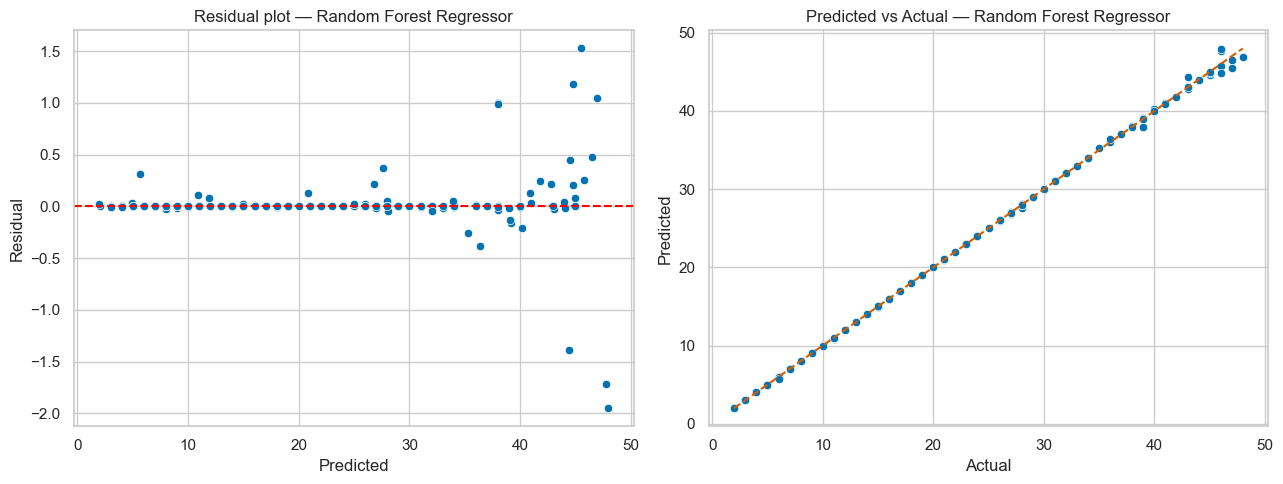

In [143]:
best_model_name = results_df.iloc[0]["Model"]
best_model = all_regression_models[best_model_name]
best_pred = best_model.predict(X_test_scaled)
residuals = y_test - best_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(x=best_pred, y=residuals, ax=axes[0])
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Residual")
axes[0].set_title(f"Residual plot — {best_model_name}")

sns.scatterplot(x=y_test, y=best_pred, ax=axes[1])
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
axes[1].plot(lims, lims, "r--")
axes[1].set_xlabel("Actual"); axes[1].set_ylabel("Predicted")
axes[1].set_title(f"Predicted vs Actual — {best_model_name}")
plt.tight_layout()
plt.savefig("../models/regression_residuals.png", bbox_inches="tight")
plt.show()


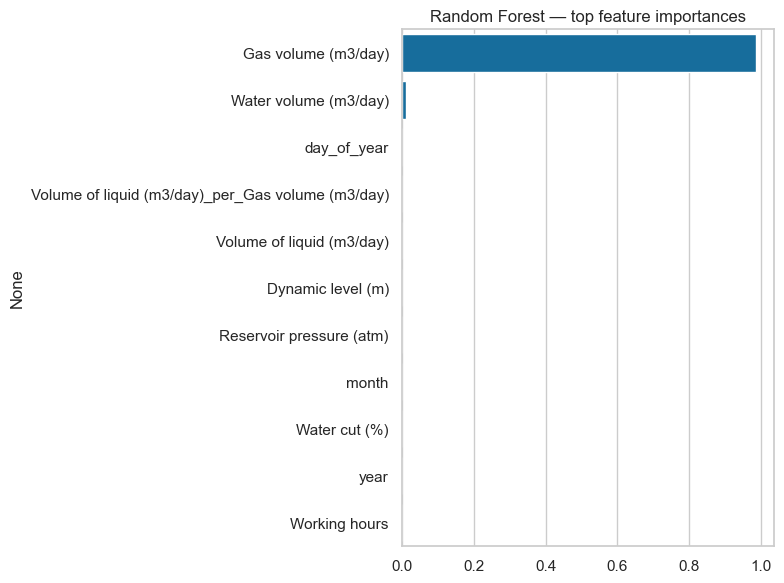

In [144]:
# Feature importance for a tree-based model
rf_model = all_regression_models.get("Random Forest Regressor")
if rf_model is not None and hasattr(rf_model, "feature_importances_"):
    importances = pd.Series(rf_model.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False).head(15)
    plt.figure(figsize=(8, 6))
    sns.barplot(x=importances.values, y=importances.index)
    plt.title("Random Forest — top feature importances")
    plt.tight_layout()
    plt.savefig("../models/regression_feature_importance.png", bbox_inches="tight")
    plt.show()


## SAVING MODELS

In [145]:
import joblib

# Add the tuned models too, so the GUI can show them alongside the 10 baseline algorithms
all_regression_models["Random Forest Regressor (tuned)"] = rf_grid.best_estimator_
all_regression_models["Support Vector Regressor (tuned)"] = svr_grid.best_estimator_

joblib.dump(all_regression_models, "../models/regression_all_models.pkl")
joblib.dump(scaler, "../models/regression_scaler.pkl")
joblib.dump(list(X_train_scaled.columns), "../models/regression_feature_names.pkl")
results_df.to_csv("../models/regression_model_scores.csv", index=False)

print(f"Saved {len(all_regression_models)} regression models, scaler, feature list, and scores to ../models/")


Saved 13 regression models, scaler, feature list, and scores to ../models/


CHECKING VERSIONS OF DEPENDENCIES

In [146]:
import sklearn
print(sklearn.__version__)

1.5.1
